In [ ]:
# Given a set of yields, compute the population weighted yields. 

# LIMS yields = 1-8Msun
# SNe yields = X to XMsun

# 6. what about isotopes of Ba. s-process vs i-process?. no do this for first lab. 

# 1. what contribution of Mg comes from AGBs vs Type II SNe? 
# 2. How does the ratio of alpha to odd-z elements change with metallicity in type ii sne?
# 3. what about at the isotope level for Mg?
# 4. how do the relative ratios of the s-process peaks change with metallicity?
# 5. how do the relative ratios of the s-process peaks change with metallicity?
# 7. how does the IMF affect things?

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
BASE_dir = "/Users/giuliaccinquegrana/Documents/GitHub/bridgce2026-stellar-nucleosynthesis"
SNE_dir = Path(f"{BASE_dir}/labs/yields/CHK25")
AGB_dir = Path(f"{BASE_dir}/labs/yields/KLC25")
initial_abundances_file = Path(f"{BASE_dir}/labs/yields/initial_comp.dat")
initial_df = pd.read_csv(initial_abundances_file, sep=r"\s+", header=None, names=["isotope", "X", "A"])
solar_abundances = dict(zip(initial_df["isotope"], initial_df["X"]))
Z_sun = 0.014

def initial_abundance(isotope, Z):
    """
    Return the initial mass fraction of an isotope at metallicity Z. 
    Metals are scaled linearly from the solar composition.
    """

    if isotope in {"p", "he4"}:

        solar_HHe = (solar_abundances["p"] + solar_abundances["he4"])

        remaining = 1.0 - Z

        if isotope == "p":
            return (solar_abundances["p"] / solar_HHe * remaining)

        return (solar_abundances["he4"] / solar_HHe * remaining)
    
    X_sun = solar_abundances.get(isotope, 0.0)

    return X_sun * Z / Z_sun


def imf(m):
    return m**-1.8

# IMF normalisation
# Population yield per unit mass of stars formed:
#                 integral[Y_i(M) phi(M) dM]
# p_i = ------------------------------------------------
#                 integral[M phi(M) dM]
# The denominator is integrated over the full stellar mass range.

M_min = 0.08
M_max = 100.0
m_imf = np.geomspace(M_min, M_max, 10000)
imf_mass = np.trapz(m_imf * imf(m_imf), m_imf)

sne_population_yields = {}

for filename in sorted(SNE_dir.iterdir()):

    if not filename.is_file():
        continue

    df = pd.read_csv(filename, sep=r"\s+", header=None, index_col=0, comment="#")

    mass = df.loc["M"].to_numpy(dtype=float)

    weights = imf(mass)

    metallicity = float(filename.stem.split("z=")[1])

    yields = {}

    for isotope in df.index:

        if isotope in {"M", "E", "Mrem"}:
            continue

        ejecta = df.loc[isotope].to_numpy(dtype=float)

        integrated_yield = np.trapz(ejecta * weights, mass)

        yields[isotope] = (integrated_yield / imf_mass)

    sne_population_yields[metallicity] = yields


sne_population_yields = pd.DataFrame.from_dict(sne_population_yields, orient="index")
sne_population_yields.index.name = "metallicity"

agb_population_yields = {}

for filename in sorted(AGB_dir.iterdir()):

    if not filename.is_file():
        continue

    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["mass", "mrem", "Z", "isotope", "A", "yield"])

    Z = float(df["Z"].iloc[0])

    yields = {}

    for isotope, isotope_df in df.groupby("isotope"):

        isotope_df = isotope_df.sort_values("mass")

        mass = isotope_df["mass"].to_numpy(dtype=float)

        mrem = isotope_df["mrem"].to_numpy(dtype=float)

        net_yield = isotope_df["yield"].to_numpy(dtype=float)

        X0 = initial_abundance(isotope, Z)

        ejecta = (net_yield + X0 * (mass - mrem))
        weights = imf(mass)
        integrated_yield = np.trapz(ejecta * weights, mass)

        yields[isotope] = (integrated_yield / imf_mass)

    agb_population_yields[Z] = yields


agb_population_yields = pd.DataFrame.from_dict(agb_population_yields, orient="index")
agb_population_yields.index.name = "metallicity"

total_population_yields = (sne_population_yields.add(agb_population_yields, fill_value=0.0))
total_population_yields.index.name = "metallicity"

# print("SN population yields:")
# display(sne_population_yields)

# print("\nAGB population yields:")
# display(agb_population_yields)

# print("\nTotal population yields:")
# display(total_population_yields)

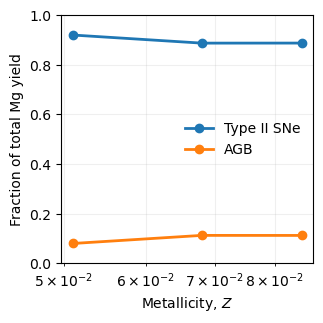

In [18]:
# ======================================================================
# 1. What fraction of Mg comes from AGBs vs Type II SNe?
# ======================================================================

# CHK25 isotope names
mg_isotopes_sne = ["Mg24", "Mg25", "Mg26"]

# KLC25 isotope names
mg_isotopes_agb = ["mg24", "mg25", "mg26"]


# ----------------------------------------------------------------------
# Total Mg yield from each population
# ----------------------------------------------------------------------

mg_sne = sne_population_yields[
    mg_isotopes_sne
].sum(axis=1)

mg_agb = agb_population_yields[
    mg_isotopes_agb
].sum(axis=1)


# ----------------------------------------------------------------------
# Sort metallicity grids
# ----------------------------------------------------------------------

Z_sne = sne_population_yields.index.to_numpy(dtype=float)
Z_agb = agb_population_yields.index.to_numpy(dtype=float)

sne_order = np.argsort(Z_sne)
agb_order = np.argsort(Z_agb)

Z_sne = Z_sne[sne_order]
Z_agb = Z_agb[agb_order]

mg_sne = mg_sne.to_numpy()[sne_order]
mg_agb = mg_agb.to_numpy()[agb_order]


# ----------------------------------------------------------------------
# Interpolate AGB yields onto SN metallicity grid
# ----------------------------------------------------------------------

mg_agb_interp = np.interp(
    Z_sne,
    Z_agb,
    mg_agb,
)


# Only use overlapping metallicity range
mask = (
    (Z_sne >= Z_agb.min())
    & (Z_sne <= Z_agb.max())
)

Z = Z_sne[mask]

mg_sne = mg_sne[mask]
mg_agb_interp = mg_agb_interp[mask]


# ----------------------------------------------------------------------
# Fractional contribution
# ----------------------------------------------------------------------

mg_total = mg_sne + mg_agb_interp

f_sne = mg_sne / mg_total
f_agb = mg_agb_interp / mg_total


# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10/3, 10/3))

ax.plot(
    Z,
    f_sne,
    marker="o",
    linewidth=2,
    label="Type II SNe",
)

ax.plot(
    Z,
    f_agb,
    marker="o",
    linewidth=2,
    label="AGB",
)

ax.set_xscale("log")

ax.set_xlabel(r"Metallicity, $Z$")
ax.set_ylabel("Fraction of total Mg yield")

ax.set_ylim(0, 1)

ax.legend(frameon=False)

ax.grid(
    which="both",
    alpha=0.2,
)

fig.tight_layout()
plt.show()